<a href="https://colab.research.google.com/github/yuzonfire907/data-science-2026/blob/main/Pertemuan%2013_Yustinus%20Budi%20Kristiawan_240401010299.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pertemuan 13 - Deep Learning & NLP Dasar**

# **Nama : Yustinus Budi Kristiawan**
# **NIM : 240401010299**
# **Kelas : IF401**

**1. Generate & Eksplorasi Dataset Non-Linear**

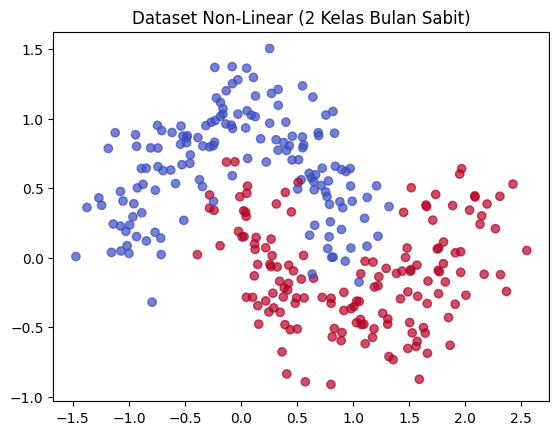

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

**2. Bangun & Latih Neural Network Sederhana**

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

**3. Evaluasi & Visualisasi Kurva Belajar**

Akurasi pada data uji: 0.900


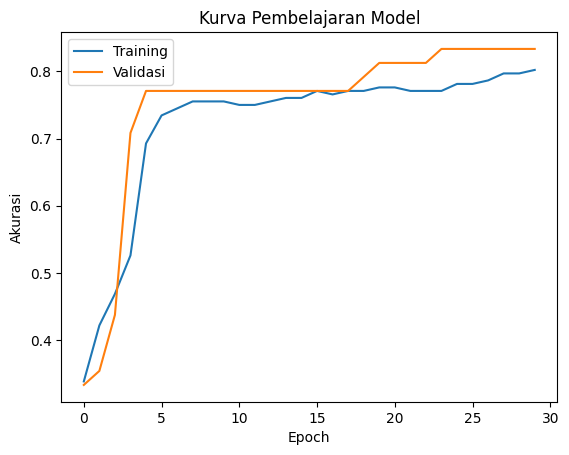

In [ ]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

Berdasarkan grafik di atas, kurva akurasi training dan validasi terlihat saling mendekat dan naik secara beriringan. Hal ini menunjukkan hasil yang baik, yang berarti model mampu belajar dengan optimal dan bisa mengenali pola data dengan pas tanpa mengalami overfitting.

**4. Siapkan Dataset Ulasan Produk**

In [ ]:
ulasan = [
    'Sepatu angkat bebannya sangat stabil dan nyaman dipakai',
    'Sarung tangan gym-nya tipis dan gampang robek',
    'Suplemen whey protein rasanya enak dan mudah larut',
    'Dumbbell 5kg yang datang berkarat parah',
    'Sabuk angkat bebannya kuat dan menyangga punggung dengan baik',
    'Botol minum shakernya bocor pas dikocok',
    'Baju olahraganya nyerap keringat dan adem',
    'Matras yoganya terlalu tipis, lutut jadi sakit',
    'Tali skippingnya mulus dipakai putaran cepat',
    'Karet resistance band-nya putus pas ditarik',
    'Rak beban sangat kokoh dan mudah dirakit',
    'Plat beban besi ukurannya tidak pas dengan stik',
    'Handuk gym-nya halus dan cepat kering',
    'Rasa minuman pre-workoutnya aneh dan bikin pusing',
    'Grip pad-nya antislip, genggaman barbel jadi mantap',
    'Jahitan di strap pergelangan tangannya lepas',
    'Tas gym-nya luas, muat banyak barang',
    'Resleting tas olahraganya macet di hari pertama',
    'Stik barbelnya lurus dan enak digenggam',
    'Sepatu larinya keras, bikin lecet tumit',
    'Foam roller-nya pas banget buat pijat otot setelah latihan',
    'Celana olahraganya terlalu ketat dan jahitannya jelek',
    'Manset tangannya nyaman dan bahannya melar',
    'Stopwatch-nya mati sendiri pas lagi dipakai',
    'Kaus kaki olahraganya tebal dan empuk',
    'Pelindung lututnya longgar, tidak menekan sama sekali',
    'Treadmill-nya berjalan mulus tanpa suara berisik',
    'Sensor detak jantung di jam tangan olahraganya tidak akurat',
    'Sepeda statisnya stabil dipakai gowes kencang',
    'Pedal sepeda statisnya patah pas baru dipakai',
    'Kapur cairnya awet dan bikin tangan tidak licin',
    'Busa pelindung stik barbel terlalu lembek',
    'Timbangan badan digitalnya akurat dan layarnya terang',
    'Angka di timbangannya berubah-ubah terus, ngaco',
    'Alat push-up sangat membantu latihan dada',
    'Besi pull-up bengkok pas dipakai bergantung',
    'Jaket saunanya tebal dan bikin cepat berkeringat',
    'Topi olahraganya luntur waktu dicuci pertama kali',
    'Ikat kepalanya pas, menahan keringat agar tidak kena mata',
    'Pengiriman alat fitnessnya lambat banget sampai sebulan'
]

# Label disesuaikan dengan urutan ulasan di atas
# 1 = Sentimen Positif, 0 = Sentimen Negatif
label = [
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0
]

**5. Ubah Teks Menjadi TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)
print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 25
['akan' 'bagus' 'banget' 'barang' 'barangnya' 'beli' 'buruk' 'cepat'
 'deskripsi' 'ekspektasi']


**6. Latih Model Klasifikasi Sentimen & Evaluasi**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.000
Positif


## Kesimpulan

1. **Materi yang Dipelajari**:
   - Membangun dan melatih jaringan saraf tiruan sederhana (Neural Network/ANN dengan aktivasi ReLU & Sigmoid) untuk mengklasifikasikan dataset non-linear.
   - Mengimplementasikan pipeline NLP dasar mencakup pemrosesan teks, ekstrasi fitur menggunakan TF-IDF Vectorizer, serta pemodelan klasifikasi sentimen ulasan produk.

2. **Temuan Utama**:
   - Model Neural Network berhasil memodelkan batas keputusan (*decision boundary*) non-linear pada dataset *make_moons* dengan akurasi dan kurva pembelajaran yang stabil (*fit*).
   - Ekstraksi fitur berbasis TF-IDF mampu mengubah data teks ulasan produk menjadi matriks numerik yang siap digunakan untuk pemodelan klasifikasi sentimen (positif/negatif).

3. **Keterbatasan & Pengembangan**:
   - Ukuran dataset teks ulasan masih sangat terbatas, sehingga pembagian data *train/test* perlu diperbesar agar evaluasi akurasi NLP lebih representatif.
   - Pemodelan NLP dapat ditingkatkan menggunakan teknik pembersihan teks (*stemming/stopword removal*) atau arsitektur Deep Learning khusus teks seperti *LSTM* atau *BERT*.